# Retail Sales Intelligence: Exploratory Data Analysis for Business Decisions

## Business Context

This notebook explores transactional online retail data to identify patterns in sales, customers, products, countries, cancellations, and order behavior.

The goal is to understand the business before building predictive models or dashboards.

## Main Questions

1. How does revenue evolve over time?
2. Which countries generate the most revenue?
3. Which products generate the most revenue?
4. How concentrated is revenue among customers?
5. What is the impact of cancellations?
6. What is the average order value?
7. What business recommendations can be derived from the data?

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = PROCESSED_DATA_DIR / "online_retail_clean.csv"
VALID_SALES_PATH = PROCESSED_DATA_DIR / "online_retail_valid_sales.csv"
CUSTOMER_SALES_PATH = PROCESSED_DATA_DIR / "online_retail_customer_sales.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
dtype_mapping = {
    "InvoiceNo": "string",
    "StockCode": "string",
    "Description": "string",
    "CustomerID": "string",
    "Country": "string",
    "InvoiceMonth": "string",
    "InvoiceDateOnly": "string",
    "InvoiceDayOfWeek": "string",
}

clean_data = pd.read_csv(
    CLEAN_DATA_PATH,
    dtype=dtype_mapping,
    parse_dates=["InvoiceDate"],
    low_memory=False,
)

valid_sales = pd.read_csv(
    VALID_SALES_PATH,
    dtype=dtype_mapping,
    parse_dates=["InvoiceDate"],
    low_memory=False,
)

customer_sales = pd.read_csv(
    CUSTOMER_SALES_PATH,
    dtype=dtype_mapping,
    parse_dates=["InvoiceDate"],
    low_memory=False,
)

clean_data.shape, valid_sales.shape, customer_sales.shape

((536641, 19), (524878, 19), (392692, 19))

In [4]:
valid_sales_revenue = valid_sales["Revenue"].sum()
customer_sales_revenue = customer_sales["Revenue"].sum()

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Clean rows",
            "Valid sales rows",
            "Customer sales rows",
            "Valid sales revenue",
            "Customer sales revenue",
            "Revenue without identified customer",
            "Revenue without identified customer share",
            "Valid sales rows without identified customer share",
        ],
        "value": [
            len(clean_data),
            len(valid_sales),
            len(customer_sales),
            valid_sales_revenue,
            customer_sales_revenue,
            valid_sales_revenue - customer_sales_revenue,
            (valid_sales_revenue - customer_sales_revenue) / valid_sales_revenue,
            (len(valid_sales) - len(customer_sales)) / len(valid_sales),
        ],
    }
)

coverage_summary

,metric,value
0,Clean rows,"536,641.00"
1,Valid sales rows,"524,878.00"
2,Customer sales rows,"392,692.00"
3,Valid sales revenue,"10,642,110.80"
4,Customer sales revenue,"8,887,208.89"
5,Revenue without identified customer,"1,754,901.91"
6,Revenue without identified customer share,0.16
7,Valid sales rows without identified customer s...,0.25


In [5]:
monthly_revenue = (
    valid_sales
    .groupby("InvoiceMonth", as_index=False)
    .agg(
        revenue=("Revenue", "sum"),
        invoices=("InvoiceNo", "nunique"),
        quantity=("Quantity", "sum"),
    )
    .sort_values("InvoiceMonth")
)

monthly_revenue

,InvoiceMonth,revenue,invoices,quantity
0,2010-12,"821,452.73",1559,358019
1,2011-01,"689,811.61",1086,387099
2,2011-02,"522,545.56",1100,282934
3,2011-03,"716,215.26",1454,376599
4,2011-04,"536,968.49",1246,307953
5,2011-05,"769,296.61",1681,395001
6,2011-06,"760,547.01",1533,388511
7,2011-07,"718,076.12",1475,399693
8,2011-08,"757,841.38",1361,421020
9,2011-09,"1,056,435.19",1837,569573


In [18]:
monthly_revenue["note"] = np.where(
    monthly_revenue["InvoiceMonth"] == "2011-12",
    "Partial month",
    "Full month"
)

monthly_revenue

,InvoiceMonth,revenue,invoices,quantity,note
0,2010-12,"821,452.73",1559,358019,Full month
1,2011-01,"689,811.61",1086,387099,Full month
2,2011-02,"522,545.56",1100,282934,Full month
3,2011-03,"716,215.26",1454,376599,Full month
4,2011-04,"536,968.49",1246,307953,Full month
5,2011-05,"769,296.61",1681,395001,Full month
6,2011-06,"760,547.01",1533,388511,Full month
7,2011-07,"718,076.12",1475,399693,Full month
8,2011-08,"757,841.38",1361,421020,Full month
9,2011-09,"1,056,435.19",1837,569573,Full month


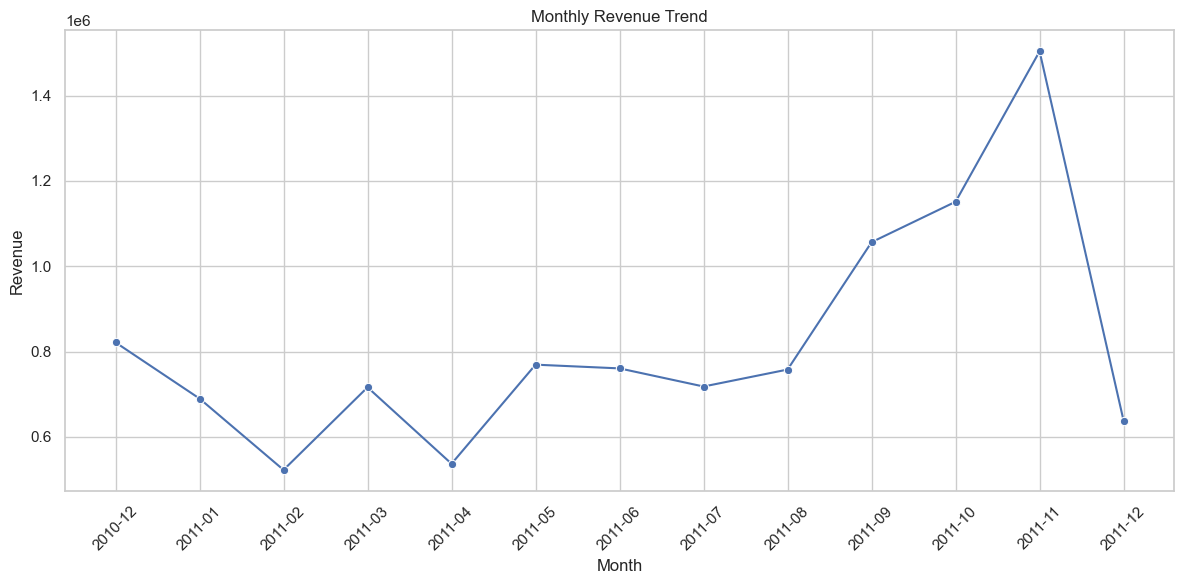

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x="InvoiceMonth", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "monthly_revenue_trend.png", dpi=300)
plt.show()

In [7]:
country_revenue = (
    valid_sales
    .groupby("Country", as_index=False)
    .agg(
        revenue=("Revenue", "sum"),
        invoices=("InvoiceNo", "nunique"),
        quantity=("Quantity", "sum"),
    )
    .sort_values("revenue", ascending=False)
)

country_revenue["revenue_share"] = country_revenue["revenue"] / country_revenue["revenue"].sum()

country_revenue.head(10)

,Country,revenue,invoices,quantity,revenue_share
36,United Kingdom,"9,001,744.09",18019,4646906,0.85
24,Netherlands,"285,446.34",94,200361,0.03
10,EIRE,"283,140.52",288,147007,0.03
14,Germany,"228,678.40",457,119154,0.02
13,France,"209,625.37",392,112060,0.02
0,Australia,"138,453.81",57,83891,0.01
31,Spain,"61,558.56",90,27933,0.01
33,Switzerland,"57,067.60",54,30617,0.01
3,Belgium,"41,196.34",98,23237,0.00
32,Sweden,"38,367.83",36,36078,0.00


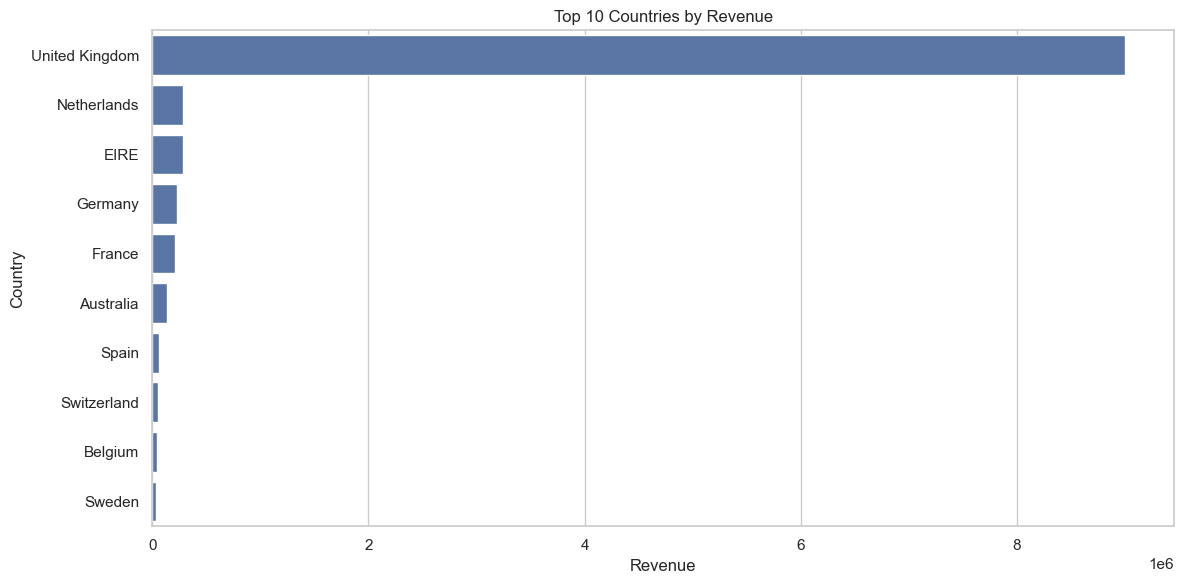

In [8]:
top_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x="revenue", y="Country")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_countries_by_revenue.png", dpi=300)
plt.show()

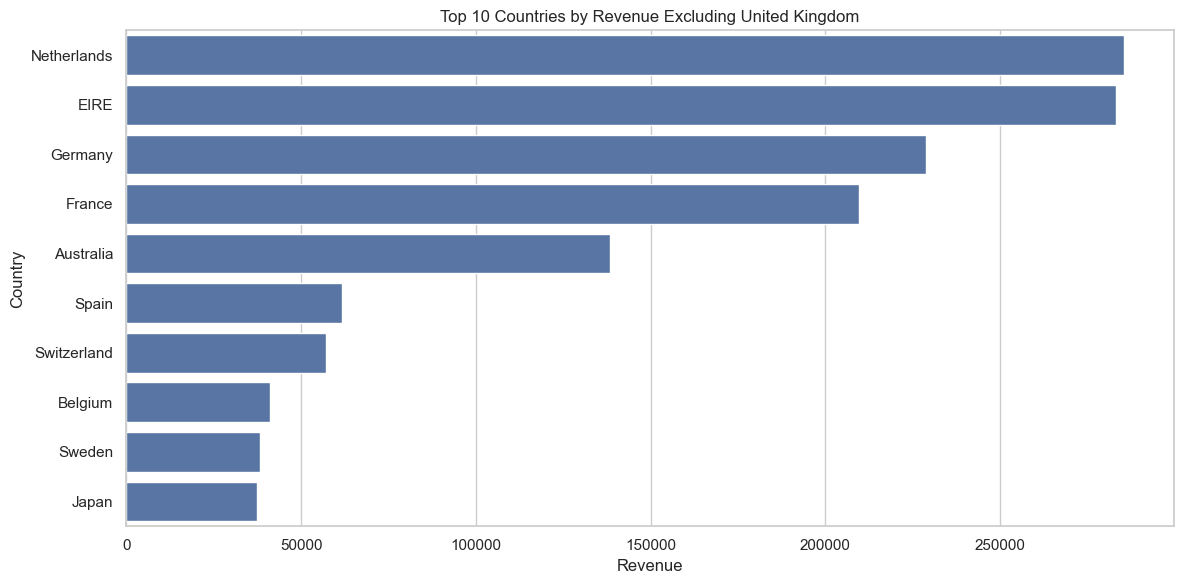

In [19]:
country_revenue_excluding_uk = country_revenue[
    country_revenue["Country"] != "United Kingdom"
].head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_revenue_excluding_uk, x="revenue", y="Country")
plt.title("Top 10 Countries by Revenue Excluding United Kingdom")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_countries_by_revenue_excluding_uk.png", dpi=300)
plt.show()

In [16]:
product_revenue = (
    valid_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        revenue=("Revenue", "sum"),
        quantity=("Quantity", "sum"),
        invoices=("InvoiceNo", "nunique"),
    )
    .sort_values("revenue", ascending=False)
)

product_revenue["revenue_share"] = (
    product_revenue["revenue"] / product_revenue["revenue"].sum()
)

product_revenue.head(10)

,StockCode,Description,revenue,quantity,invoices,revenue_share
4147,DOT,DOTCOM POSTAGE,"206,248.77",706,706,0.02
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,0.02
2665,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,0.02
3637,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189,0.01
2874,47566,PARTY BUNTING,"99,445.23",18283,1685,0.01
3616,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,0.01
2120,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,0.01
4150,POST,POSTAGE,"78,101.88",3150,1126,0.01
4148,M,Manual,"77,750.27",6984,289,0.01
2026,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,0.01


In [22]:
special_stock_codes = ["DOT", "POST", "M", "BANK CHARGES", "AMAZONFEE", "CRUK"]

product_revenue["is_special_code"] = product_revenue["StockCode"].isin(special_stock_codes)

product_revenue.head(15)

,StockCode,Description,revenue,quantity,invoices,revenue_share,is_special_code
4147,DOT,DOTCOM POSTAGE,"206,248.77",706,706,0.02,True
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,0.02,False
2665,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,0.02,False
3637,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189,0.01,False
2874,47566,PARTY BUNTING,"99,445.23",18283,1685,0.01,False
3616,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,0.01,False
2120,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,0.01,False
4150,POST,POSTAGE,"78,101.88",3150,1126,0.01,True
4148,M,Manual,"77,750.27",6984,289,0.01,True
2026,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,0.01,False


In [23]:
product_revenue_excluding_special = (
    product_revenue[~product_revenue["is_special_code"]]
    .sort_values("revenue", ascending=False)
)

product_revenue_excluding_special.head(10)

,StockCode,Description,revenue,quantity,invoices,revenue_share,is_special_code
1340,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,0.02,False
2665,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,0.02,False
3637,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189,0.01,False
2874,47566,PARTY BUNTING,"99,445.23",18283,1685,0.01,False
3616,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,0.01,False
2120,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,0.01,False
2026,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,0.01,False
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,1160,0.01,False
3413,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1455,0.01,False
3056,79321,CHILLI LIGHTS,"54,096.36",10302,661,0.01,False


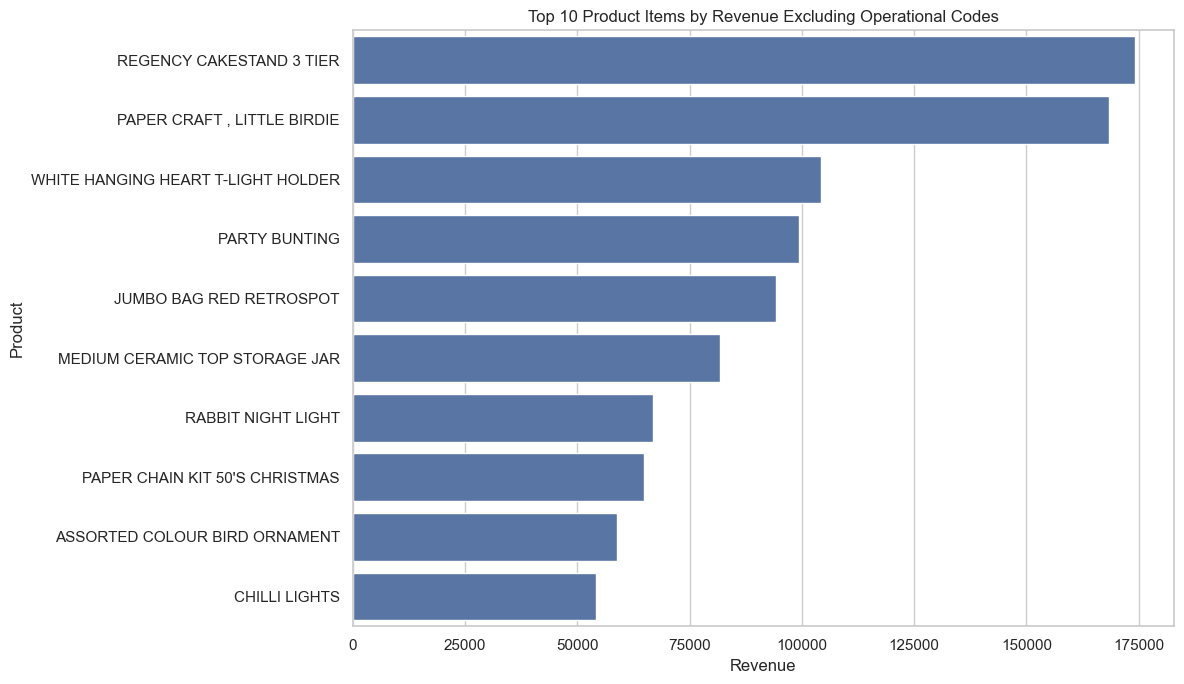

In [24]:
top_products_excluding_special = product_revenue_excluding_special.head(10).copy()
top_products_excluding_special["Product"] = (
    top_products_excluding_special["Description"].str.slice(0, 45)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_products_excluding_special, x="revenue", y="Product")
plt.title("Top 10 Product Items by Revenue Excluding Operational Codes")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_products_by_revenue_excluding_special_codes.png", dpi=300)
plt.show()

### Product Ranking Interpretation

The initial product ranking includes operational or administrative codes such as `DOTCOM POSTAGE`, `POSTAGE`, and `Manual`. These records are relevant for total revenue accounting, but they should not be interpreted as regular product items.

For product performance analysis, operational codes were separated from regular product items. This avoids confusing shipping, manual adjustments, or administrative charges with actual merchandise performance.

The item `PAPER CRAFT , LITTLE BIRDIE` also shows unusually high revenue from a very small number of invoices, so it should be treated as a potential outlier requiring further business validation.

In [9]:
customer_revenue = (
    customer_sales
    .groupby("CustomerID", as_index=False)
    .agg(
        revenue=("Revenue", "sum"),
        invoices=("InvoiceNo", "nunique"),
        quantity=("Quantity", "sum"),
    )
    .sort_values("revenue", ascending=False)
)

customer_revenue["revenue_share"] = customer_revenue["revenue"] / customer_revenue["revenue"].sum()
customer_revenue["cumulative_revenue_share"] = customer_revenue["revenue_share"].cumsum()
customer_revenue["customer_rank"] = np.arange(1, len(customer_revenue) + 1)

customer_revenue.head(10)

,CustomerID,revenue,invoices,quantity,revenue_share,cumulative_revenue_share,customer_rank
1689,14646,"280,206.02",73,196915,0.03,0.03,1
4201,18102,"259,657.30",60,64124,0.03,0.06,2
3728,17450,"194,390.79",46,69973,0.02,0.08,3
3008,16446,"168,472.50",2,80997,0.02,0.10,4
1879,14911,"143,711.17",201,80240,0.02,0.12,5
55,12415,"124,914.53",21,77374,0.01,0.13,6
1333,14156,"117,210.08",55,57768,0.01,0.14,7
3771,17511,"91,062.38",31,64549,0.01,0.16,8
2702,16029,"80,850.84",63,40108,0.01,0.16,9
0,12346,"77,183.60",1,74215,0.01,0.17,10


In [10]:
top_10_customer_share = customer_revenue.head(10)["revenue"].sum() / customer_revenue["revenue"].sum()
top_100_customer_share = customer_revenue.head(100)["revenue"].sum() / customer_revenue["revenue"].sum()

print(f"Top 10 customer revenue share: {top_10_customer_share:.2%}")
print(f"Top 100 customer revenue share: {top_100_customer_share:.2%}")

Top 10 customer revenue share: 17.30%
Top 100 customer revenue share: 40.61%


In [20]:
top_100_share_total_valid_revenue = (
    customer_revenue.head(100)["revenue"].sum() / valid_sales["Revenue"].sum()
)

print(
    "Top 100 customers share over total valid sales revenue: "
    f"{top_100_share_total_valid_revenue:.2%}"
)

Top 100 customers share over total valid sales revenue: 33.91%


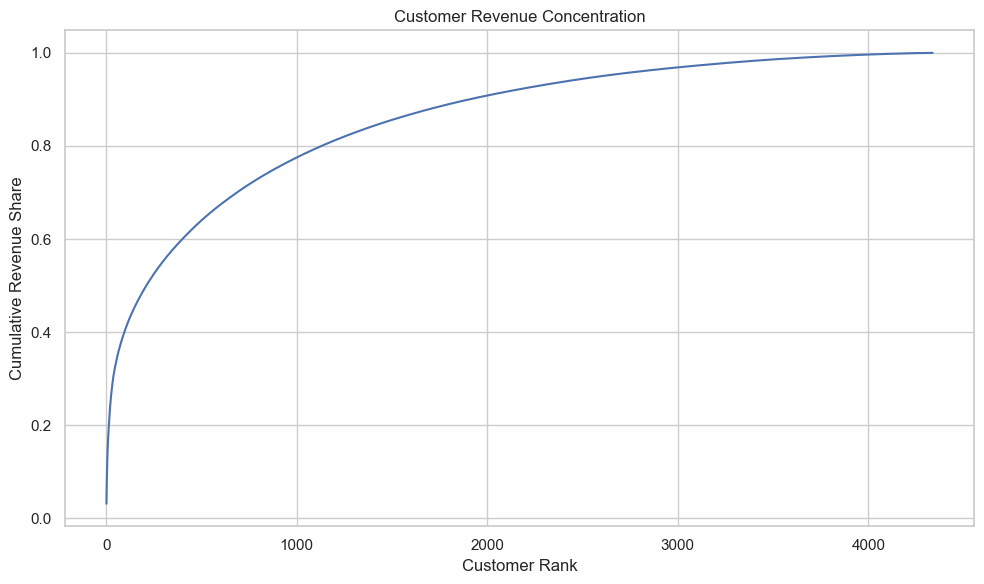

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=customer_revenue,
    x="customer_rank",
    y="cumulative_revenue_share",
)
plt.title("Customer Revenue Concentration")
plt.xlabel("Customer Rank")
plt.ylabel("Cumulative Revenue Share")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "customer_revenue_concentration.png", dpi=300)
plt.show()

In [12]:
cancellation_data = clean_data[clean_data["is_cancellation"]].copy()

cancellation_summary = pd.DataFrame(
    {
        "metric": [
            "Cancellation rows",
            "Cancellation invoices",
            "Cancellation revenue impact",
            "Cancellation rows share over clean data",
        ],
        "value": [
            len(cancellation_data),
            cancellation_data["InvoiceNo"].nunique(),
            cancellation_data["Revenue"].sum(),
            len(cancellation_data) / len(clean_data),
        ],
    }
)

cancellation_summary

,metric,value
0,Cancellation rows,"9,251.00"
1,Cancellation invoices,"3,836.00"
2,Cancellation revenue impact,"-893,979.73"
3,Cancellation rows share over clean data,0.02


In [21]:
cancellation_impact_abs = abs(cancellation_data["Revenue"].sum())
cancellation_impact_share = cancellation_impact_abs / valid_sales["Revenue"].sum()

print(f"Cancellation impact as share of valid sales revenue: {cancellation_impact_share:.2%}")

Cancellation impact as share of valid sales revenue: 8.40%


In [13]:
invoice_revenue = (
    valid_sales
    .groupby("InvoiceNo", as_index=False)
    .agg(
        order_value=("Revenue", "sum"),
        items=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
    )
)

invoice_revenue.describe()

,order_value,items,unique_products
count,"19,960.00","19,960.00","19,960.00"
mean,533.17,279.18,26.03
std,"1,780.41",955.01,46.98
min,0.38,1.00,1.00
25%,151.70,69.00,6.00
50%,303.30,150.00,15.00
75%,493.46,296.00,29.00
max,"168,469.60","80,995.00","1,110.00"


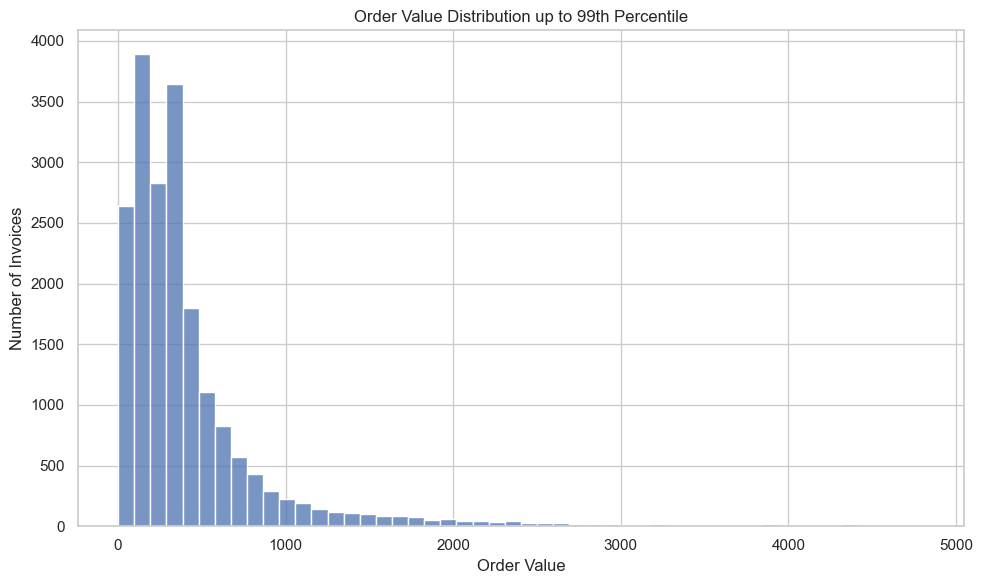

In [14]:
order_value_p99 = invoice_revenue["order_value"].quantile(0.99)

plt.figure(figsize=(10, 6))
sns.histplot(
    invoice_revenue[invoice_revenue["order_value"] <= order_value_p99]["order_value"],
    bins=50,
)
plt.title("Order Value Distribution up to 99th Percentile")
plt.xlabel("Order Value")
plt.ylabel("Number of Invoices")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "order_value_distribution_p99.png", dpi=300)
plt.show()

## Preliminary Insights

- The dataset required cleaning before analysis because it included duplicate rows, cancellations, missing customer identifiers, non-positive quantities, and non-positive unit prices.
- Valid sales revenue reached 10.64M, but customer-identified revenue reached 8.89M. This means 16.49% of valid revenue cannot be linked to a known customer.
- The United Kingdom dominates the business, representing approximately 85% of valid sales revenue. International performance should therefore be analyzed separately to avoid hiding smaller but relevant markets.
- Revenue increased strongly from September to November 2011, with November being the highest-revenue month. December 2011 should not be compared directly because it is only a partial month.
- The top 10 identified customers generate 17.30% of customer-identified revenue, while the top 100 generate 40.61%. This suggests meaningful customer concentration.
- Cancellations represent a negative revenue impact of approximately 894K, equivalent to 8.40% of valid sales revenue. This should be analyzed as a business and operational issue rather than discarded as simple noise.
- Order values are highly skewed. The median order value is much lower than the mean, indicating that a small number of large orders can distort average-based interpretations.
- Product ranking requires caution because some high-revenue records are operational codes such as postage or manual adjustments, not regular merchandise.

## Business Recommendations

- Monitor high-value customers separately because a small group contributes a significant share of customer-identified revenue.
- Analyze international markets excluding the United Kingdom to identify growth opportunities hidden by the dominant domestic market.
- Investigate cancellation patterns by product, country, and customer to identify operational friction.
- Use median and percentile-based metrics for order value analysis instead of relying only on averages.
- Treat missing CustomerID as a data quality limitation before performing customer segmentation or retention analysis.